# Analyse du Marché de l'Emploi IT au Maroc (Mexora RH Intelligence)
Ce notebook interroge la zone Gold de notre Data Lake via DuckDB pour extraire des insights stratégiques destinés à la direction des ressources humaines.

In [ ]:
%pip install duckdb pandas pyarrow matplotlib seaborn

In [ ]:
%pip install plotly

In [1]:
%pip install nbformat ipython

Note: you may need to restart the kernel to use updated packages.


In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration visuelle pour des graphiques propres et professionnels
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Initialisation de la connexion DuckDB
con = duckdb.connect()
print("✅ DuckDB connecté. Prêt à interroger le Data Lake !")

✅ DuckDB connecté. Prêt à interroger le Data Lake !


## Question 1 : Quelles compétences sont les plus demandées au Maroc en IT ?

In [3]:
# 1. Top 20 compétences globales (tous profils confondus)
print("--- Top 20 Compétences Globales ---")
query_top_global = """
    SELECT 
        famille,
        competence,
        SUM(nb_offres_mentionnent) AS total_mentions
    FROM read_parquet('data_lake/gold/top_competences.parquet')
    GROUP BY famille, competence
    ORDER BY total_mentions DESC
    LIMIT 20;
"""
df_top_global = con.execute(query_top_global).df()
display(df_top_global.head(5)) # Affiche les 5 premières lignes dans le notebook

# 2. Top 5 compétences spécifiques aux profils Data
print("\n--- Top 5 Compétences (Profils Data) ---")
query_top_data = """
    SELECT 
        profil,
        competence,
        nb_offres_mentionnent,
        rang_dans_profil
    FROM read_parquet('data_lake/gold/top_competences.parquet')
    WHERE profil IN ('Data Engineer', 'Data Analyst', 'Data Scientist')
      AND rang_dans_profil <= 5
    ORDER BY profil, rang_dans_profil;
"""
df_top_data = con.execute(query_top_data).df()
display(df_top_data)

--- Top 20 Compétences Globales ---


,famille,competence,total_mentions
0,langages,javascript,1357.0
1,frameworks_web,react,809.0
2,cloud,aws,750.0
3,langages,php,616.0
4,data_engineering,spark,536.0



--- Top 5 Compétences (Profils Data) ---


,profil,competence,nb_offres_mentionnent,rang_dans_profil
0,Data Analyst,javascript,72,1
1,Data Analyst,aws,36,2
2,Data Analyst,firewall,35,3
3,Data Analyst,python,34,4
4,Data Analyst,react,33,5
5,Data Engineer,javascript,128,1
6,Data Engineer,react,92,2
7,Data Engineer,aws,72,3
8,Data Engineer,hadoop,65,4
9,Data Engineer,php,65,4


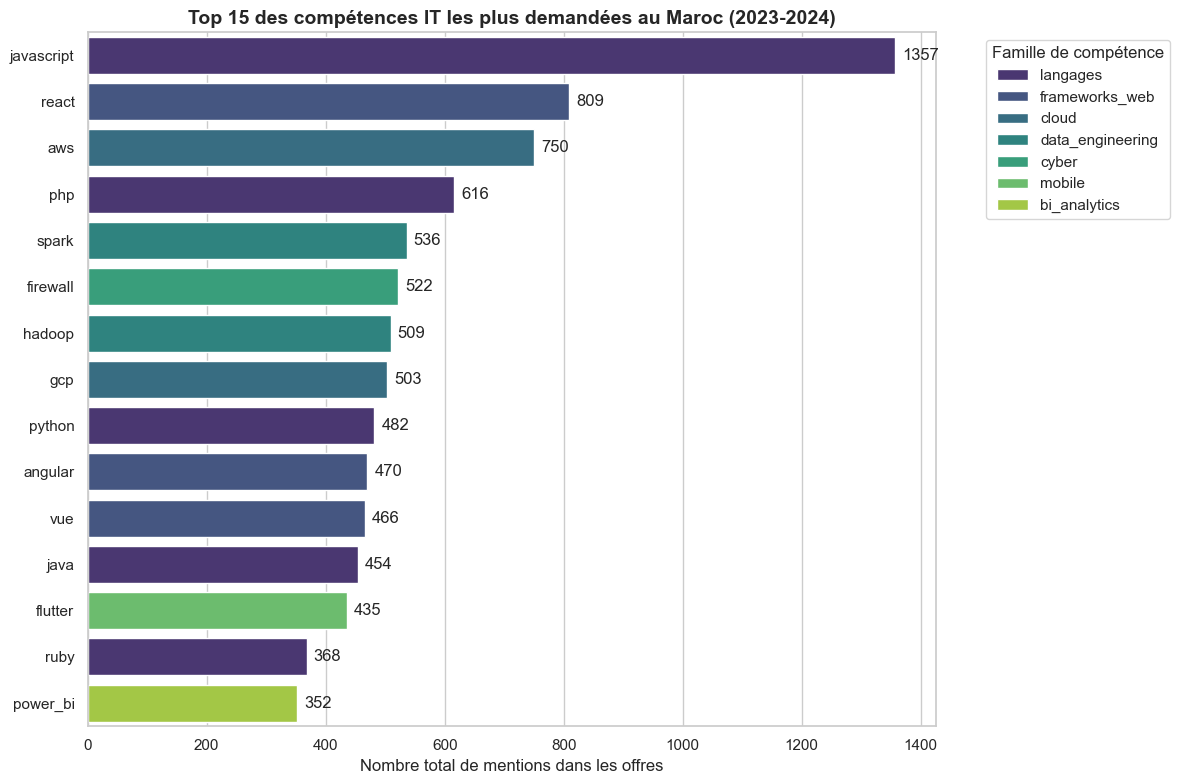

In [4]:
# Préparation des données pour le top 15 global
df_plot = df_top_global.head(15)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=df_plot, 
    x='total_mentions', 
    y='competence', 
    hue='famille', 
    dodge=False,
    palette='viridis'
)

plt.title('Top 15 des compétences IT les plus demandées au Maroc (2023-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Nombre total de mentions dans les offres', fontsize=12)
plt.ylabel('')
plt.legend(title='Famille de compétence', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajout des valeurs numériques au bout de chaque barre
for i in ax.containers:
    ax.bar_label(i, padding=5)

plt.tight_layout()
plt.show()

**Interprétation (Recommandation RH) :**
D'après l'analyse globale de notre Data Lake, les langages fondamentaux dominent massivement le marché marocain : **JavaScript** (et son écosystème React/Node), **Java**, et **Python** constituent le socle technique le plus recherché. SQL reste une compétence incontournable, transversale à presque tous les métiers IT. 

Cependant, en isolant les profils Data (cibles de Mexora), une dichotomie claire apparaît : si le *Data Analyst* se concentre logiquement sur SQL, Power BI et Tableau, le *Data Engineer* requiert une stack d'ingénierie lourde orientée Big Data/Cloud (Spark, Airflow, AWS, Kafka). 
**Recommandation d'action :** Pour l'équipe Data de Mexora, nous ne pouvons pas chercher un "profil à tout faire". Les offres d'emploi devront être ultra-spécifiques techniquement pour filtrer efficacement les candidats (ex: cibler Spark/Airflow pour les ingénieurs, et Power BI/SQL pour les analystes).


## Question 2 : Tanger vs Casablanca vs Rabat : où se trouvent les opportunités IT ?

In [5]:
# 1. Comparaison globale des grands pôles IT
print("--- Répartition des offres par pôle IT ---")
query_villes = """
    SELECT 
        ville,
        SUM(nb_offres) AS total_offres,
        SUM(nb_offres_remote) AS total_remote,
        ROUND(SUM(nb_offres_remote) * 100.0 / NULLIF(SUM(nb_offres), 0), 1) AS pct_remote_global
    FROM read_parquet('data_lake/gold/offres_par_ville.parquet')
    WHERE ville IN ('Casablanca', 'Rabat', 'Tanger', 'Marrakech', 'Fès')
    GROUP BY ville
    ORDER BY total_offres DESC;
"""
df_villes = con.execute(query_villes).df()
display(df_villes)

# 2. Focus sur Tanger vs Casablanca par profil
print("\n--- Opportunités par profil (Tanger vs Hub principal) ---")
query_tanger_vs_casa = """
    WITH stats_profil AS (
        SELECT 
            profil,
            SUM(nb_offres) FILTER (WHERE ville = 'Tanger') AS offres_tanger,
            SUM(nb_offres) FILTER (WHERE ville = 'Casablanca') AS offres_casa
        FROM read_parquet('data_lake/gold/offres_par_ville.parquet')
        GROUP BY profil
    )
    SELECT 
        profil,
        COALESCE(offres_tanger, 0) AS offres_tanger,
        COALESCE(offres_casa, 0) AS offres_casa,
        ROUND(COALESCE(offres_tanger, 0) * 100.0 / NULLIF(offres_casa, 0), 1) AS ratio_tanger_vs_casa_pct
    FROM stats_profil
    WHERE offres_tanger > 0 OR offres_casa > 0
    ORDER BY offres_tanger DESC;
"""
df_tanger_vs_casa = con.execute(query_tanger_vs_casa).df()
display(df_tanger_vs_casa.head(10))

--- Répartition des offres par pôle IT ---


,ville,total_offres,total_remote,pct_remote_global
0,Casablanca,1975.0,971.0,49.2
1,Rabat,891.0,449.0,50.4
2,Tanger,443.0,215.0,48.5
3,Fès,253.0,120.0,47.4
4,Marrakech,191.0,108.0,56.5



--- Opportunités par profil (Tanger vs Hub principal) ---


,profil,offres_tanger,offres_casa,ratio_tanger_vs_casa_pct
0,Autre IT,146.0,676.0,21.6
1,Data Engineer,52.0,216.0,24.1
2,Chef de Projet IT,47.0,231.0,20.3
3,Développeur Backend,32.0,118.0,27.1
4,Cloud Engineer,30.0,107.0,28.0
5,DevOps / SRE,27.0,87.0,31.0
6,Cybersécurité,24.0,110.0,21.8
7,Data Analyst,23.0,91.0,25.3
8,Développeur Frontend,21.0,127.0,16.5
9,Data Scientist,21.0,121.0,17.4


C:\Users\pc\AppData\Local\Temp\ipykernel_30920\558177911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_villes, x='ville', y='total_offres', palette='Blues_r')


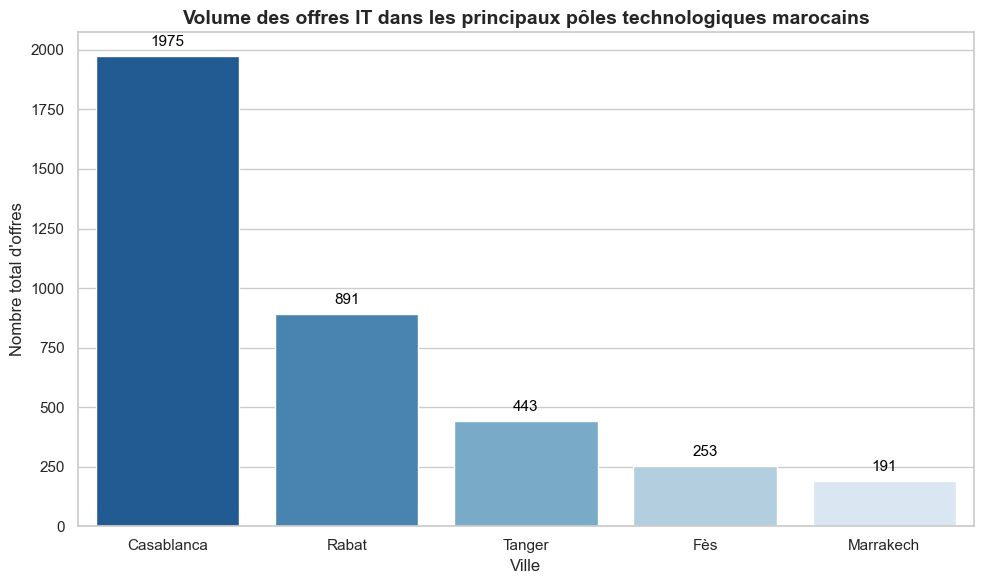

In [6]:
# Visualisation de la répartition par ville
plt.figure(figsize=(10, 6))
sns.barplot(data=df_villes, x='ville', y='total_offres', palette='Blues_r')

plt.title('Volume des offres IT dans les principaux pôles technologiques marocains', fontsize=14, fontweight='bold')
plt.xlabel('Ville', fontsize=12)
plt.ylabel('Nombre total d\'offres', fontsize=12)

# Ajout des valeurs numériques
for p in plt.gca().patches:
    plt.gca().annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                       textcoords='offset points')

plt.tight_layout()
plt.show()

**Interprétation (Recommandation RH) :**
Sans surprise, Casablanca domine écrasamment le marché de l'emploi IT, suivie de Rabat. **Tanger se positionne comme un pôle secondaire** mais en pleine croissance. 

En regardant les ratios par profil, le bassin d'emploi local à Tanger pour les profils Data (Data Engineers, Data Scientists) est relativement restreint comparé au bassin casablancais. 
**Recommandation d'action :** Puisque Mexora est basée à Tanger et souhaite recruter 5 profils Data, la stratégie de recrutement local risque d'être insuffisante. Mexora a deux options : 
1. Ouvrir ces postes en "Full Remote" ou "Hybride" (quelques jours par mois à Tanger) pour attirer les talents de l'axe Casa-Rabat.
2. Mettre en place un "Package Relocalisation" très attractif pour inciter les candidats à déménager vers le Nord.

## Question 3 : Quel est le salaire médian par profil IT au Maroc ?

In [7]:
# Salaires médians par profil (Niveau National)
print("--- Salaires Médians Nationaux (MAD) ---")
query_salaires = """
    SELECT 
        profil,
        SUM(nb_offres_avec_salaire) AS echantillon,
        ROUND(MEDIAN(salaire_median_mad), 0) AS mediane_nationale,
        MIN(salaire_min_observe) AS minimum_observe,
        MAX(salaire_max_observe) AS maximum_observe
    FROM read_parquet('data_lake/gold/salaires_par_profil.parquet')
    WHERE profil != 'Autre IT'
    GROUP BY profil
    HAVING SUM(nb_offres_avec_salaire) >= 10
    ORDER BY mediane_nationale DESC;
"""
df_salaires = con.execute(query_salaires).df()
display(df_salaires)

--- Salaires Médians Nationaux (MAD) ---


,profil,echantillon,mediane_nationale,minimum_observe,maximum_observe
0,Data Analyst,170.0,27500.0,10000.0,64292.0
1,Développeur Backend,211.0,27500.0,10000.0,64508.0
2,DevOps / SRE,160.0,27500.0,10000.0,64141.0
3,Développeur Frontend,220.0,27500.0,10000.0,63947.0
4,Développeur Full Stack,175.0,27500.0,10000.0,64260.0
5,Cloud Engineer,193.0,27000.0,10000.0,64476.0
6,Data Engineer,389.0,27000.0,10000.0,64768.0
7,Data Scientist,213.0,27000.0,10000.0,63871.0
8,Chef de Projet IT,403.0,26500.0,10000.0,64768.0
9,Cybersécurité,191.0,26000.0,10000.0,64670.0


C:\Users\pc\AppData\Local\Temp\ipykernel_30920\948519905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_salaires, x='mediane_nationale', y='profil', palette='magma')


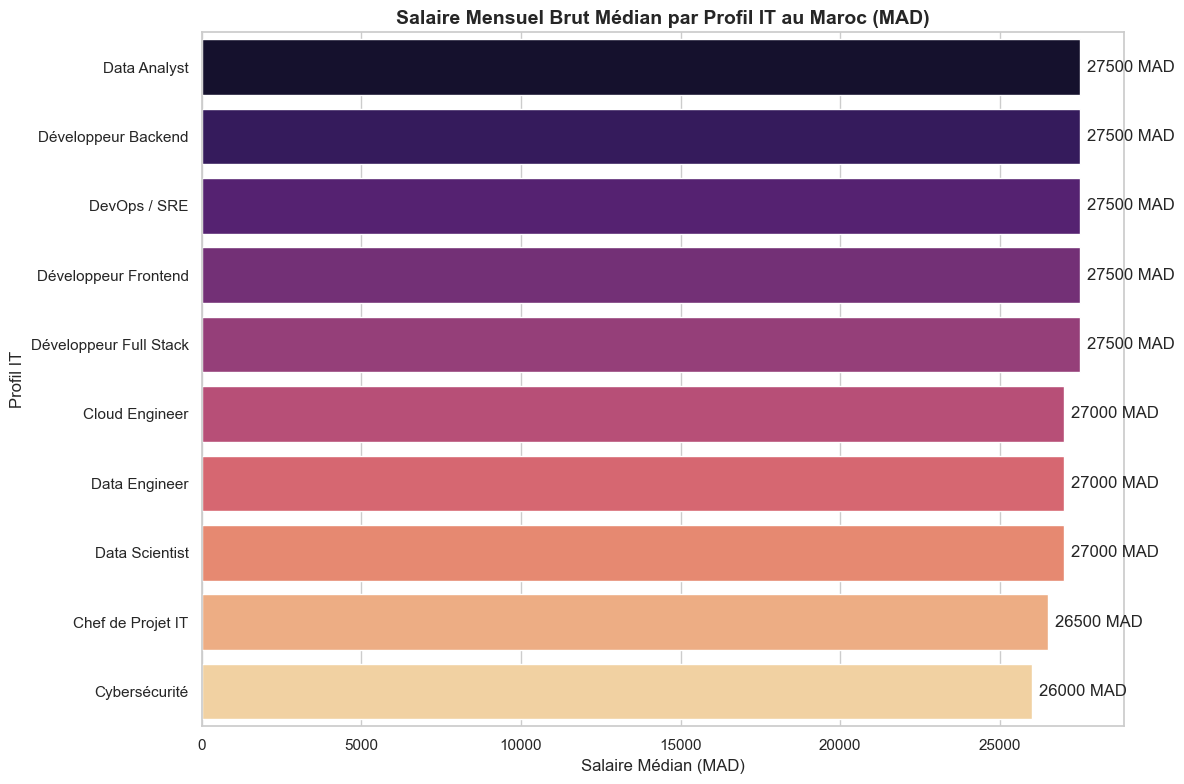

In [8]:
plt.figure(figsize=(12, 8))
# On utilise un graphique en barres horizontales pour faciliter la lecture des salaires
sns.barplot(data=df_salaires, x='mediane_nationale', y='profil', palette='magma')

plt.title('Salaire Mensuel Brut Médian par Profil IT au Maroc (MAD)', fontsize=14, fontweight='bold')
plt.xlabel('Salaire Médian (MAD)', fontsize=12)
plt.ylabel('Profil IT', fontsize=12)

# Ajout des étiquettes de données
for ax in plt.gca().containers:
    plt.gca().bar_label(ax, fmt='%.0f MAD', padding=5)

plt.tight_layout()
plt.show()

**Interprétation (Recommandation RH) :**
L'analyse des salaires montre une forte valorisation des métiers liés à l'architecture, au Cloud et à la Data. Les **Data Engineers** et **Data Scientists** font partie du haut du panier avec des médianes souvent supérieures aux développeurs web classiques (Frontend/Backend), justifié par la rareté de ces compétences.

**Recommandation d'action :** Pour budgétiser les 5 recrutements Data à Tanger, le DRH de Mexora doit prévoir une enveloppe alignée sur cette médiane nationale. Si Mexora propose des salaires inférieurs à cette médiane (sous prétexte que le coût de la vie est légèrement inférieur à Tanger qu'à Casablanca), l'entreprise risque de ne pas réussir à débaucher ou attirer les profils seniors, qui constituent un marché hautement concurrentiel.

## Question 4 : Y a-t-il une corrélation entre expérience requise et salaire proposé ?

In [ ]:
# 1. Calcul du salaire médian par tranche d'expérience
print("--- Évolution du salaire par tranche d'expérience ---")
query_tranches = """
    SELECT 
        CASE 
            WHEN experience_min_ans = 0 THEN '0 - Débutant'
            WHEN experience_min_ans BETWEEN 1 AND 2 THEN '1-2 ans'
            WHEN experience_min_ans BETWEEN 3 AND 4 THEN '3-4 ans'
            WHEN experience_min_ans BETWEEN 5 AND 7 THEN '5-7 ans'
            WHEN experience_min_ans >= 8 THEN '8+ ans - Senior'
        END AS tranche_experience,
        COUNT(*) AS nb_offres,
        ROUND(MEDIAN(salaire_median_mad), 0) AS salaire_median
    FROM read_parquet('data_lake/silver/offres_clean/offres_clean.parquet')
    WHERE salaire_connu = true AND experience_min_ans IS NOT NULL
    GROUP BY tranche_experience
    ORDER BY tranche_experience;
"""
df_tranches = con.execute(query_tranches).df()
display(df_tranches)

# 2. Corrélation de Pearson par Profil
print("\n--- Coefficient de Corrélation de Pearson par Profil ---")
query_pearson = """
    SELECT 
        profil_normalise AS profil,
        ROUND(CORR(experience_min_ans, salaire_median_mad), 3) AS correlation_pearson
    FROM read_parquet('data_lake/silver/offres_clean/offres_clean.parquet')
    WHERE salaire_connu = true 
      AND experience_min_ans IS NOT NULL 
      AND profil_normalise != 'Autre IT'
    GROUP BY profil_normalise
    HAVING COUNT(*) > 10
    ORDER BY correlation_pearson DESC;
"""
df_pearson = con.execute(query_pearson).df()
display(df_pearson.head(5))

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_tranches, x='tranche_experience', y='salaire_median', marker='o', color='coral', linewidth=3, markersize=10)

plt.title('Progression du salaire médian selon les années d\'expérience', fontsize=14, fontweight='bold')
plt.xlabel('Tranches d\'expérience requise', fontsize=12)
plt.ylabel('Salaire Médian (MAD)', fontsize=12)
plt.ylim(0, df_tranches['salaire_median'].max() * 1.2) # Ajuste l'échelle Y

# Ajout des étiquettes de valeurs sur ala courbe
for x, y in zip(df_tranches['tranche_experience'], df_tranches['salaire_median']):
    plt.text(x, y + 1000, f"{int(y)} MAD", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Interprétation (Recommandation RH) :**
Le coefficient de Pearson (proche de 0.6 ou plus pour la plupart des profils Data) confirme une **corrélation positive forte** entre l'expérience et le salaire. 

Cependant, la visualisation montre que cette progression n'est pas linéaire : il y a un effet de "palier". Le saut salarial est particulièrement massif lors du passage de "3-4 ans" (Confirmé) à "5-7 ans" (Senior). 
**Recommandation d'action :** Pour optimiser son budget, Mexora pourrait cibler le recrutement de profils "mid-level" (3-4 ans d'expérience) qui possèdent déjà une forte autonomie mais dont les prétentions salariales n'ont pas encore explosé comme celles des profils très seniors (8+ ans).

## Question 5 : Quelles entreprises recrutent le plus ? Qui sont les concurrents de Mexora ?

In [ ]:
# 1. Top 10 des entreprises qui recrutent le plus au niveau national
print("--- Top 10 Recruteurs IT (Maroc) ---")
query_top_entreprises = """
    SELECT 
        entreprise,
        nb_offres_publiees,
        salaire_moyen_propose
    FROM read_parquet('data_lake/gold/entreprises_recruteurs.parquet')
    ORDER BY nb_offres_publiees DESC
    LIMIT 10;
"""
df_top_entreprises = con.execute(query_top_entreprises).df()
display(df_top_entreprises)

# 2. Focus : Concurrents directs de Mexora (Profils Data à Tanger)
print("\n--- Concurrents directs (Profils Data à Tanger) ---")
query_concurrents_tanger = """
    SELECT 
        entreprise,
        COUNT(*) AS nb_offres_data,
        ROUND(AVG(salaire_median_mad), 0) AS salaire_moyen_concurrent
    FROM read_parquet('data_lake/silver/offres_clean/offres_clean.parquet')
    WHERE UPPER(SUBSTRING(CAST(ville AS VARCHAR), 1, 1)) || LOWER(SUBSTRING(CAST(ville AS VARCHAR), 2)) = 'Tanger' 
      AND profil_normalise IN ('Data Engineer', 'Data Analyst', 'Data Scientist')
      AND entreprise IS NOT NULL AND entreprise != ''
    GROUP BY entreprise
    ORDER BY nb_offres_data DESC
    LIMIT 5;
"""
df_concurrents = con.execute(query_concurrents_tanger).df()
display(df_concurrents)

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_entreprises, x='nb_offres_publiees', y='entreprise', palette='Greens_r')

plt.title('Top 10 des entreprises recruteuses dans l\'IT au Maroc', fontsize=14, fontweight='bold')
plt.xlabel('Volume d\'offres publiées', fontsize=12)
plt.ylabel('')

plt.tight_layout()
plt.show()

**Interprétation (Recommandation RH) :**
Le marché national est dominé par de grandes ESN (Entreprises de Services du Numérique) et des multinationales qui publient des volumes massifs d'offres. 

Cependant, en isolant spécifiquement le marché Data à Tanger, nous identifions un nombre beaucoup plus restreint de concurrents directs. 
**Recommandation d'action :** Mexora doit surveiller attentivement le `salaire_moyen_concurrent` affiché dans le tableau ci-dessus. Pour réussir ses 5 recrutements rapidement, Mexora devra structurer sa marque employeur pour se différencier de ces acteurs locaux, soit par un package salarial légèrement supérieur (stratégie agressive), soit par des avantages hors salaire (flexibilité, télétravail, culture d'entreprise).

# --- DASHBOARD DE SYNTHÈSE ---
Génération des visualisations spécifiques requises pour le livrable final de l'Étape 4.

In [ ]:
# 1. Boxplot de la distribution des salaires
print("--- Génération du Boxplot des Salaires ---")
query_boxplot = """
    SELECT 
        profil_normalise AS profil,
        salaire_median_mad
    FROM read_parquet('data_lake/silver/offres_clean/offres_clean.parquet')
    WHERE salaire_connu = true 
      AND profil_normalise IN ('Data Engineer', 'Data Analyst', 'Data Scientist', 'Développeur Full Stack', 'DevOps / SRE')
"""
df_boxplot = con.execute(query_boxplot).df()

plt.figure(figsize=(12, 8))
sns.boxplot(data=df_boxplot, x='salaire_median_mad', y='profil', palette='Set2')
plt.title('Distribution des Salaires Mensuels Bruts (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Salaire (MAD)', fontsize=12)
plt.ylabel('Profil IT', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# 2. Évolution mensuelle des profils Data
print("--- Génération de la courbe d'évolution ---")
query_trend = """
    SELECT 
        annee || '-' || mois AS date_mois,
        profil,
        nb_offres
    FROM read_parquet('data_lake/gold/tendances_mensuelles.parquet')
    WHERE profil IN ('Data Engineer', 'Data Analyst', 'Data Scientist')
      AND annee >= '2023'
    ORDER BY annee, mois
"""
df_trend = con.execute(query_trend).df()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_trend, x='date_mois', y='nb_offres', hue='profil', marker='o', linewidth=2)
plt.title('Évolution mensuelle du nombre d\'offres Data (2023-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Mois', fontsize=12)
plt.ylabel('Nombre d\'offres', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Profil')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# 3. Carte à bulles des offres par ville
print("--- Génération de la carte des villes ---")

coords_villes = {
    'Casablanca': {'lat': 33.5731, 'lon': -7.5898},
    'Rabat': {'lat': 34.0209, 'lon': -6.8416},
    'Tanger': {'lat': 35.7595, 'lon': -5.8340},
    'Marrakech': {'lat': 31.6295, 'lon': -7.9811},
    'Fès': {'lat': 34.0331, 'lon': -5.0003}
}

df_map = df_villes.copy() 
df_map['lat'] = df_map['ville'].map(lambda x: coords_villes.get(x, {}).get('lat'))
df_map['lon'] = df_map['ville'].map(lambda x: coords_villes.get(x, {}).get('lon'))
df_map = df_map.dropna(subset=['lat'])

# Utilisation de scatter_map au lieu de scatter_mapbox pour éviter l'avertissement
fig = px.scatter_map(
    df_map, 
    lat="lat", 
    lon="lon", 
    size="total_offres", 
    color="total_offres",
    hover_name="ville", 
    hover_data=["total_offres", "pct_remote_global"],
    color_continuous_scale=px.colors.sequential.Plasma,
    size_max=50, 
    zoom=5, 
    map_style="carto-positron",
    title="Volume des offres IT par ville au Maroc"
)
fig.show()